In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("cleaned_data 2022-2025.csv")
df

,Year,State,Shopping expenditure,Purchase of automotive fuel expenditure,Transportation expenditure,Food & beverage expenditure,Accomodation expenditure,Entrance ticket expenditure,Other expenditure,Visited household expediture,...,Average receipts per trip (RM),Average length of stay (day),Household,Income mean (RM),Income median (RM),Expenditure mean (RM),Expenditure burden (%),Inflation (%),Receipts per visitor (RM),Receipts per household (RM)
0,2019,Johor,2010838,1439192,466143,971456,740566,319504,352689,1109290,...,387,2.54,966000,8013.0,6427.0,4793.0,74.58,0.67,519.13,7670.81
1,2020,Johor,1119630,258308,188347,430119,130846,42027,67138,195159,...,307,1.85,1017727,7264.0,5690.0,4976.0,87.45,-1.46,335.77,2389.64
2,2021,Johor,495151,164824,89338,152467,77690,75139,60462,136779,...,330,2.06,1045400,7890.5,6284.5,5159.0,82.09,2.47,342.26,1197.63
3,2022,Johor,1601286,739862,408115,708035,576209,234307,154571,465968,...,377,2.34,1073400,8517.0,6879.0,5342.0,77.66,3.42,394.96,4553.75
4,2023,Johor,2112096,976142,532169,1017258,967492,250643,231663,611655,...,406,2.18,1101800,9000.5,7295.5,5634.5,77.23,2.42,423.85,6080.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2020,Terengganu,1181271,172369,80933,543289,58179,20821,67872,129773,...,224,2.06,282373,6051.0,4790.0,4373.0,91.29,-1.28,303.91,7985.89
74,2021,Terengganu,419566,100429,34569,206405,106273,57983,9205,49682,...,238,2.20,290400,6649.5,5334.0,4584.5,85.95,3.44,264.59,3388.43
75,2022,Terengganu,1491085,457090,195005,524112,292024,71732,126640,205609,...,263,2.69,298600,7248.0,5878.0,4796.0,81.59,3.05,328.64,11262.56
76,2023,Terengganu,1650481,582975,248973,791250,359323,98603,165869,294844,...,302,2.59,306900,7437.5,6252.5,5007.5,80.09,1.80,356.43,13659.17


In [3]:
features = [
    "Shopping expenditure",
    "Purchase of automotive fuel expenditure",
    "Transportation expenditure",
    "Food & beverage expenditure",
    "Accomodation expenditure",
    "Entrance ticket expenditure",
    "Other expenditure",
    "Visited household expediture"
]

X = df[features]
y = df["Inflation (%)"]

In [4]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

In [5]:
kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [6]:
r2_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

In [7]:
mae_scores = -cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

In [8]:
rmse_scores = np.sqrt(
    -cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
)

In [9]:
print("\n========================================")
print("10-FOLD CROSS-VALIDATION RESULTS")
print("========================================")

print("\nR² scores:")
print(r2_scores)

print("\nMean R²:", r2_scores.mean())
print("Std R²:", r2_scores.std())

print("\nMAE scores:")
print(mae_scores)

print("\nMean MAE:", mae_scores.mean())
print("Std MAE:", mae_scores.std())

print("\nRMSE scores:")
print(rmse_scores)

print("\nMean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())


10-FOLD CROSS-VALIDATION RESULTS

R² scores:
[-1.68667029 -0.24400427  0.37977504  0.01083423  0.1762056   0.09349552
 -1.39144705  0.51904324  0.44041042 -0.77890753]

Mean R²: -0.24812650938272163
Std R²: 0.7402062199788236

MAE scores:
[1.08577892 1.39984188 0.85798209 1.29538999 1.97956047 0.67200003
 1.17206219 0.91999547 1.12528803 1.24431142]

Mean MAE: 1.1752210499960658
Std MAE: 0.3385477377604955

RMSE scores:
[1.62698227 1.79837282 1.15956229 1.52970229 2.15813057 0.80059597
 1.30393983 1.1344326  1.27673419 1.35055985]

Mean RMSE: 1.4139012685668473
Std RMSE: 0.36254129678353686


In [10]:
y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=kf
)

In [11]:
print("\n========================================")
print("OVERALL CROSS-VALIDATED PERFORMANCE")
print("========================================")

print("MAE :", mean_absolute_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("R²  :", r2_score(y, y_pred))


OVERALL CROSS-VALIDATED PERFORMANCE
MAE : 1.1749754429302246
RMSE: 1.4631813644617522
R²  : 0.16561739366800898


In [12]:
model.fit(X, y)

regressor = model.named_steps["regressor"]


In [13]:
print("\n========================================")
print("REGRESSION COEFFICIENTS")
print("========================================")

for feature, coefficient in zip(features, regressor.coef_):
    print(f"{feature}: {coefficient:.6f}")

print("\nIntercept:", regressor.intercept_)


REGRESSION COEFFICIENTS
Shopping expenditure: -0.758580
Purchase of automotive fuel expenditure: 3.133189
Transportation expenditure: 0.660970
Food & beverage expenditure: -1.949694
Accomodation expenditure: 0.167076
Entrance ticket expenditure: 0.950622
Other expenditure: -0.163289
Visited household expediture: -1.992887

Intercept: 1.4684615384615385


In [14]:
results = pd.DataFrame({
    "Actual Inflation (%)": y.values,
    "Predicted Inflation (%)": y_pred
})

print("\n========================================")
print("ACTUAL VS PREDICTED")
print("========================================")

print(results.head(20))


ACTUAL VS PREDICTED
    Actual Inflation (%)  Predicted Inflation (%)
0                   0.67                 4.030205
1                  -1.46                 0.625394
2                   2.47                 1.466668
3                   3.42                 2.817115
4                   2.42                 2.665669
5                   1.76                 1.731159
6                   1.36                 0.862692
7                  -1.77                 1.064478
8                   2.56                 2.176105
9                   2.59                 2.346566
10                  1.69                 1.511731
11                  1.30                 1.052631
12                  0.38                 0.863684
13                 -1.47                 1.014930
14                  3.11                 1.370072
15                  2.78                 0.730544
16                  1.69                 0.952685
17                  1.00                 0.503509
18                  0.08     

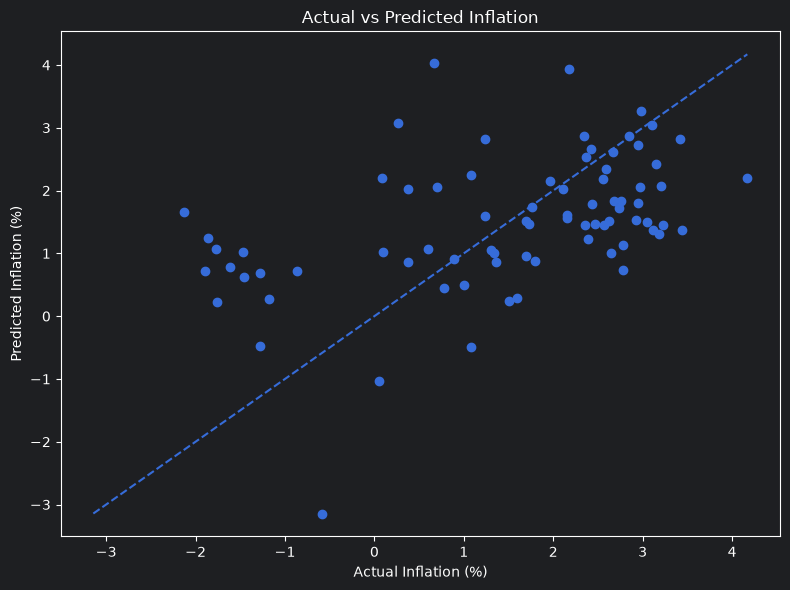

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y,
    y_pred
)

# Perfect prediction line
min_value = min(y.min(), y_pred.min())
max_value = max(y.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Inflation (%)")
plt.ylabel("Predicted Inflation (%)")
plt.title("Actual vs Predicted Inflation")

plt.tight_layout()
plt.show()
